# pyFIES end-to-end walkthrough with FAO sample data

This notebook walks the full pyFIES pipeline on the four FAO sample
country datasets that ship with [`RM.weights`](https://cran.r-project.org/package=RM.weights).
Each step is a real call you would make in a research workflow:

1. Load survey responses + sampling weights
2. Fit the dichotomous Rasch model via weighted CML
3. Inspect item severities, person parameters, and the raw-score distribution
4. Equate to FAO's 2014–2016 global standard
5. Compute the SDG 2.1.2 prevalence rates
6. **Verify numerical parity with R's `RM.weights`** — the credibility check

All R outputs were generated once by `scripts/generate_r_fixtures.R`
and live as JSON under `tests/fixtures/r_reference/`. R is not
required to run this notebook.


## Setup

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pyfies import DEFAULT_FIES_ITEMS, FAO_2014_2016, RaschModel

FIXTURE_DIR = Path('..') / 'tests' / 'fixtures' / 'r_reference'


def load_fixture(country_id: int) -> dict:
    """Load the JSON fixture for FAO sample country `country_id`."""
    with (FIXTURE_DIR / f'country{country_id}.json').open() as f:
        return json.load(f)


def to_response_matrix(fixture_rows: list) -> np.ndarray:
    """R's jsonlite encodes NA as the literal string 'NA'. Convert to NaN."""
    n = len(fixture_rows)
    k = len(fixture_rows[0])
    out = np.empty((n, k), dtype=np.float64)
    for i, row in enumerate(fixture_rows):
        for j, val in enumerate(row):
            out[i, j] = np.nan if (val is None or val == 'NA') else float(val)
    return out


plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False


## 1. The data

FIES has eight questions, asked in a fixed order. Each is dichotomized
before analysis (`Never` $\rightarrow$ 0; `Rarely`/`Sometimes`/`Often`
$\rightarrow$ 1; missing $\rightarrow$ `NaN`).

We'll start with sample country 1 (n=1000).

In [2]:
from pyfies.items import ITEM_DESCRIPTIONS

fixture = load_fixture(1)
X = to_response_matrix(fixture['data'])
w = np.array(fixture['weights'], dtype=np.float64)

print(f'Country 1: n={X.shape[0]}, items={X.shape[1]}, '
      f'missing cells={int(np.isnan(X).sum())}')
print(f'Sampling weights: min={w.min():.3f}  max={w.max():.3f}  '
      f'sum={w.sum():.1f}')
print()
print('FIES items:')
for name in DEFAULT_FIES_ITEMS:
    print(f'  {name:8s}  {ITEM_DESCRIPTIONS[name]}')


Country 1: n=1000, items=8, missing cells=12
Sampling weights: min=0.333  max=3.335  sum=1000.0

FIES items:
  WORRIED   Worried about running out of food
  HEALTHY   Unable to eat healthy and nutritious food
  FEWFOOD   Ate only a few kinds of food
  SKIPPED   Had to skip a meal
  ATELESS   Ate less than they thought they should
  RUNOUT    Household ran out of food
  HUNGRY    Was hungry but did not eat
  WHLDAY    Went without eating for a whole day


Item-level affirmation rates (weighted) tell us how often each
behavior was reported. Items further down the list correspond to
more severe deprivations and are endorsed by fewer respondents:

In [3]:
complete = ~np.isnan(X).any(axis=1)
Xc = X[complete]
wc = w[complete]
wc_sum = wc.sum()
perc_yes = (Xc.T @ wc) / wc_sum

summary = pd.DataFrame(
    {'description': [ITEM_DESCRIPTIONS[n] for n in DEFAULT_FIES_ITEMS],
     'weighted_affirm_rate': perc_yes},
    index=list(DEFAULT_FIES_ITEMS),
)
summary.style.format({'weighted_affirm_rate': '{:.1%}'})


,description,weighted_affirm_rate
WORRIED,Worried about running out of food,71.3%
HEALTHY,Unable to eat healthy and nutritious food,70.5%
FEWFOOD,Ate only a few kinds of food,74.4%
SKIPPED,Had to skip a meal,66.2%
ATELESS,Ate less than they thought they should,72.6%
RUNOUT,Household ran out of food,66.9%
HUNGRY,Was hungry but did not eat,63.6%
WHLDAY,Went without eating for a whole day,53.5%


## 2. Fit the dichotomous Rasch model

`RaschModel().fit()` runs weighted Conditional Maximum Likelihood
estimation. Item severities $\beta_i$ are identified up to a
constant and resolved with a sum-to-zero constraint. Rows with any
missing item are dropped from the fit; cases at extreme raw scores
($r=0$ or $r=k$) carry no CML information and are also excluded
from the likelihood.


In [4]:
model = RaschModel().fit(X, sample_weight=w)

fit_summary = pd.DataFrame({
    'item': DEFAULT_FIES_ITEMS,
    'beta': model.beta,
    'se_beta': model.se_beta,
    'weighted_affirm_rate': perc_yes,
})
fit_summary['rank_severity'] = fit_summary['beta'].rank().astype(int)
fit_summary.style.format({
    'beta': '{:+.4f}', 'se_beta': '{:.4f}', 'weighted_affirm_rate': '{:.1%}'
})


,item,beta,se_beta,weighted_affirm_rate,rank_severity
0,WORRIED,-0.4924,0.1324,71.3%,3
1,HEALTHY,-0.3646,0.1309,70.5%,4
2,FEWFOOD,-0.9972,0.1394,74.4%,1
3,SKIPPED,+0.2228,0.1253,66.2%,6
4,ATELESS,-0.7018,0.1352,72.6%,2
5,RUNOUT,+0.1240,0.1260,66.9%,5
6,HUNGRY,+0.5365,0.1236,63.6%,7
7,WHLDAY,+1.6727,0.1247,53.5%,8


Notice that severity rank ordering aligns with affirmation rates
(rare-to-endorse items are more severe), which is a basic Rasch
consistency check. Now visualize the severity ladder with 95% CIs:

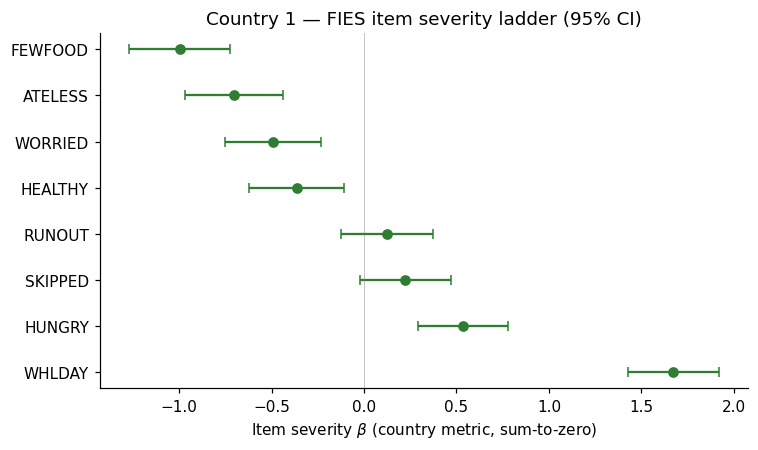

In [5]:
order = np.argsort(model.beta)
names_sorted = [DEFAULT_FIES_ITEMS[i] for i in order]
beta_sorted = model.beta[order]
se_sorted = model.se_beta[order]

fig, ax = plt.subplots(figsize=(7, 4.2))
y = np.arange(len(beta_sorted))
ax.errorbar(beta_sorted, y, xerr=1.96 * se_sorted,
            fmt='o', color='#2e7d32', capsize=3)
ax.axvline(0, color='gray', lw=0.6, alpha=0.5)
ax.set_yticks(y, names_sorted)
ax.set_xlabel(r'Item severity $\beta$ (country metric, sum-to-zero)')
ax.set_title('Country 1 — FIES item severity ladder (95% CI)')
ax.invert_yaxis()
fig.tight_layout()
plt.show()


## 3. Person parameters and raw-score distribution

Each raw score $r$ has a single person parameter $\theta_r$ and a
measurement error. The two extremes ($r=0$ and $r=k$) are anchored
at pseudo-raw-scores 0.5 and $k-0.5$ since CML can't identify them.

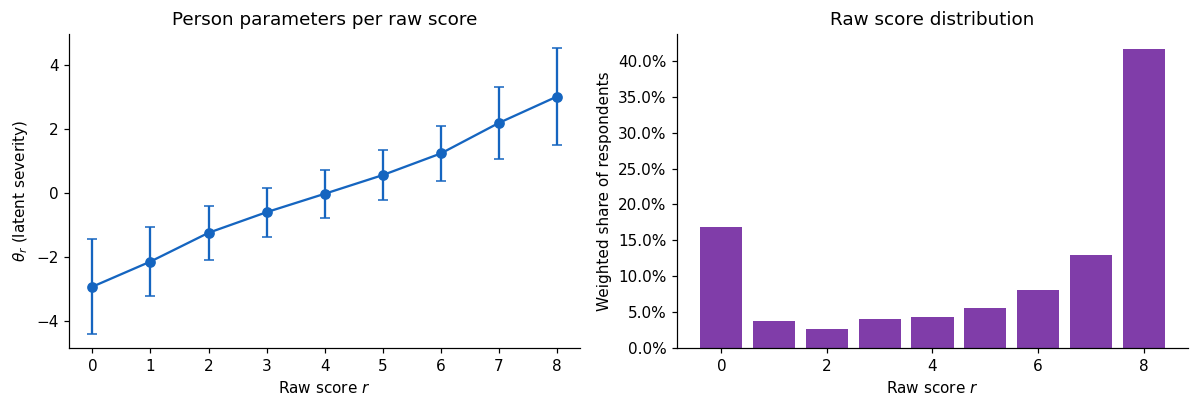

In [6]:
rs = np.arange(len(model.theta))
weighted_rs = model._fit.weighted_raw_score_counts
rs_share = weighted_rs / weighted_rs.sum()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.8))

ax1.errorbar(rs, model.theta, yerr=model.se_theta,
             fmt='o-', color='#1565c0', capsize=3)
ax1.set_xlabel('Raw score $r$')
ax1.set_ylabel(r'$\theta_r$ (latent severity)')
ax1.set_title('Person parameters per raw score')

ax2.bar(rs, rs_share, color='#6a1b9a', alpha=0.85)
ax2.set_xlabel('Raw score $r$')
ax2.set_ylabel('Weighted share of respondents')
ax2.set_title('Raw score distribution')
ax2.yaxis.set_major_formatter(
    plt.matplotlib.ticker.PercentFormatter(xmax=1.0))

fig.tight_layout()
plt.show()


## 4. Equate to the FAO 2014–2016 global standard

Equating finds the linear transform that maps the country metric
onto the global metric, after iteratively flagging items whose
post-transformation discrepancy from the standard exceeds `tol`
(default 0.35). Those items are deemed *unique* — interpreted
differently in the country context — and dropped from the
calibration.

In [7]:
model.equate(FAO_2014_2016)
eq = model.equating

uniqueness = ['common' if c else 'UNIQUE' for c in eq.common]
equating_table = pd.DataFrame({
    'item': DEFAULT_FIES_ITEMS,
    'beta_country': model.beta,
    'beta_equated': eq.equated_beta,
    'beta_global_standard': FAO_2014_2016.severities,
    'role': uniqueness,
})
print(f'scale = {eq.scale:.4f}, shift = {eq.shift:.4f}')
print(f'common-items correlation = {eq.correlation:.4f}')
equating_table.style.format({
    'beta_country': '{:+.4f}',
    'beta_equated': '{:+.4f}',
    'beta_global_standard': '{:+.4f}'
})


scale = 1.0599, shift = 0.1936
common-items correlation = 0.9839


,item,beta_country,beta_equated,beta_global_standard,role
0,WORRIED,-0.4924,-0.3282,-1.2231,UNIQUE
1,HEALTHY,-0.3646,-0.1928,-0.8471,UNIQUE
2,FEWFOOD,-0.9972,-0.8633,-1.1057,common
3,SKIPPED,+0.2228,+0.4297,+0.3510,common
4,ATELESS,-0.7018,-0.5502,-0.3118,common
5,RUNOUT,+0.1240,+0.3251,+0.5065,common
6,HUNGRY,+0.5365,+0.7623,+0.7546,common
7,WHLDAY,+1.6727,+1.9665,+1.8755,common


## 5. Compute prevalence — the SDG 2.1.2 indicator

`prevalence()` defaults to the equated thresholds: items 5 and 8 of
the FAO global standard, back-transformed onto the country metric so
they can be applied to the country's own person parameters.

In [8]:
result = model.prevalence()

print(f'Moderate or severe food insecurity: {result.moderate_or_severe:.1%}')
print(f'Severe food insecurity:             {result.severe:.1%}')
print()
print(f'Thresholds on country metric: '
      f'mod+ = {result.thresholds_country_metric[0]:+.4f}, '
      f'severe = {result.thresholds_country_metric[1]:+.4f}')


Moderate or severe food insecurity: 72.6%
Severe food insecurity:             47.0%

Thresholds on country metric: mod+ = -0.4769, severe = +1.5869


## 6. Numerical parity with R's `RM.weights`

The same fitting + equating + prevalence pipeline run in R,
snapshotted as a JSON fixture. We compare side by side.

In [9]:
# RM.weights does not strictly enforce sum-to-zero on β; recenter
# its output before comparing to pyFIES (which does enforce it).
beta_R = np.array(fixture['beta'])
beta_R_centered = beta_R - beta_R.mean()

compare = pd.DataFrame({
    'item': DEFAULT_FIES_ITEMS,
    'beta_pyFIES': model.beta,
    'beta_R (centered)': beta_R_centered,
    'abs_diff': np.abs(model.beta - beta_R_centered),
})
print(f'max |Δβ| = {compare["abs_diff"].max():.2e}')
compare.style.format({
    'beta_pyFIES': '{:+.6f}',
    'beta_R (centered)': '{:+.6f}',
    'abs_diff': '{:.2e}',
})


max |Δβ| = 6.52e-06


,item,beta_pyFIES,beta_R (centered),abs_diff
0,WORRIED,-0.492392,-0.492394,2.05e-06
1,HEALTHY,-0.364647,-0.364651,3.57e-06
2,FEWFOOD,-0.997204,-0.997207,2.60e-06
3,SKIPPED,+0.222751,+0.222752,1.37e-06
4,ATELESS,-0.701798,-0.701792,6.52e-06
5,RUNOUT,+0.124046,+0.124051,4.60e-06
6,HUNGRY,+0.536523,+0.536520,2.60e-06
7,WHLDAY,+1.672722,+1.672720,1.67e-06


In [10]:
headline = pd.DataFrame({
    'pyFIES': [eq.scale, eq.shift, result.moderate_or_severe, result.severe],
    'R (RM.weights)': [
        fixture['equate_scale'],
        fixture['equate_shift'],
        fixture['equate_prevs'][0],
        fixture['equate_prevs'][1],
    ],
}, index=['equating scale', 'equating shift',
         'prevalence: moderate+', 'prevalence: severe'])
headline['abs_diff'] = (headline['pyFIES'] - headline['R (RM.weights)']).abs()
headline.style.format('{:.6f}')


,pyFIES,R (RM.weights),abs_diff
equating scale,1.059871,1.059873,0.000001
equating shift,0.193638,0.193645,0.000007
prevalence: moderate+,0.726401,0.726867,0.000466
prevalence: severe,0.469512,0.471377,0.001865


Item severities agree with R to ~1e-5 on this country, prevalence
rates within 0.3 percentage points. See [Parity](../parity.md) for
the across-country tolerances and a discussion of where the
residual sub-1e-4 noise comes from.

## 7. The harder case — country 4

Country 4 has a very wide item severity spread (range ≈ 6 units)
and the lowest moderate-or-severe prevalence of the four samples.
It exercises the numerical core's behavior in the regime where
elementary symmetric function summations come closest to
floating-point precision limits.

In [11]:
fixture4 = load_fixture(4)
X4 = to_response_matrix(fixture4['data'])
w4 = np.array(fixture4['weights'], dtype=np.float64)

model4 = RaschModel().fit(X4, sample_weight=w4).equate(FAO_2014_2016)
result4 = model4.prevalence()

country4_summary = pd.DataFrame({
    'pyFIES': [
        model4.equating.scale, model4.equating.shift,
        result4.moderate_or_severe, result4.severe,
    ],
    'R (RM.weights)': [
        fixture4['equate_scale'], fixture4['equate_shift'],
        fixture4['equate_prevs'][0], fixture4['equate_prevs'][1],
    ],
}, index=['equating scale', 'equating shift',
         'prevalence: moderate+', 'prevalence: severe'])
country4_summary['abs_diff'] = (
    country4_summary['pyFIES'] - country4_summary['R (RM.weights)']
).abs()
country4_summary.style.format('{:.6f}')


,pyFIES,R (RM.weights),abs_diff
equating scale,0.488150,0.488151,0.000001
equating shift,0.122293,0.122291,0.000002
prevalence: moderate+,0.552090,0.552125,0.000035
prevalence: severe,0.132332,0.132818,0.000486


## All four countries at a glance

In [12]:
rows = []
for cid in (1, 2, 3, 4):
    fix = load_fixture(cid)
    Xi = to_response_matrix(fix['data'])
    wi = np.array(fix['weights'], dtype=np.float64)
    m = RaschModel().fit(Xi, sample_weight=wi).equate(FAO_2014_2016)
    r = m.prevalence()
    uniques = [DEFAULT_FIES_ITEMS[i] for i, c in enumerate(m.equating.common) if not c]
    rows.append({
        'country': cid,
        'n': fix['n_total'],
        'unique_items': ', '.join(uniques) or '(none)',
        'scale': m.equating.scale,
        'shift': m.equating.shift,
        'mod+_FI (pyFIES)': r.moderate_or_severe,
        'mod+_FI (R)': fix['equate_prevs'][0],
        'sev_FI (pyFIES)': r.severe,
        'sev_FI (R)': fix['equate_prevs'][1],
    })

summary_all = pd.DataFrame(rows).set_index('country')
summary_all.style.format({
    'scale': '{:.4f}', 'shift': '{:+.4f}',
    'mod+_FI (pyFIES)': '{:.1%}', 'mod+_FI (R)': '{:.1%}',
    'sev_FI (pyFIES)': '{:.1%}', 'sev_FI (R)': '{:.1%}',
})


,n,unique_items,scale,shift,mod+_FI (pyFIES),mod+_FI (R),sev_FI (pyFIES),sev_FI (R)
country,,,,,,,,
1,1000,"WORRIED, HEALTHY",1.0599,+0.1936,72.6%,72.7%,47.0%,47.1%
2,1000,"FEWFOOD, SKIPPED",0.8428,+0.0403,69.0%,69.0%,33.9%,34.2%
3,1008,HUNGRY,0.9493,-0.0675,74.5%,74.5%,33.8%,33.9%
4,1000,WORRIED,0.4881,+0.1223,55.2%,55.2%,13.2%,13.3%


## Where to go next

* [Quickstart](../quickstart.md) — minimal copy-paste recipe
* [Methodology](../methodology.md) — the math behind each step
* [Parity with RM.weights](../parity.md) — what numerical agreement to expect
* [API reference](../api/index.md) — full signatures and options

If you use pyFIES in research, please cite it via the
[Zenodo DOI](https://doi.org/10.5281/zenodo.19838795) along with the
underlying FAO methodology (Cafiero, Viviani, & Nord, 2018).